In [2]:
import pickle
import torch
from tqdm import tqdm
from minf.data import FieldPDBDataset
from minf.models import Autoencoder, SirenNet
from minf.utils import plot_field
from torch.utils.data import DataLoader
import numpy as np
import yt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

In [3]:
resolution = 32
rotation = 40

fd = FieldPDBDataset("../data/7qam.pdb", resolution=resolution, single_property=1)
dl = DataLoader(fd, batch_size=4, shuffle=True)
dl_test = DataLoader(fd, batch_size=4, shuffle=False)

yt : [INFO     ] 2025-02-11 18:30:37,143 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:37,143 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:37,144 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:37,144 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:37,145 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:37,204 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:37,212 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:37,213 Creating volume
yt : [INFO     ] 2025-02-11 18:30:37,229 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:37,229 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


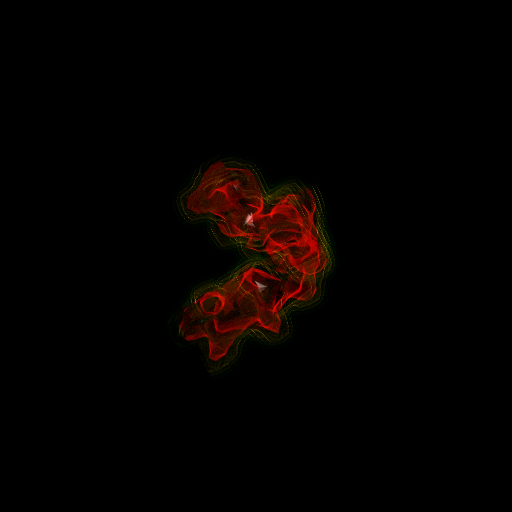

yt : [INFO     ] 2025-02-11 18:30:37,382 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:37,383 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:37,383 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:37,383 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:37,383 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:37,424 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:37,431 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:37,431 Creating volume
yt : [INFO     ] 2025-02-11 18:30:37,448 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:37,449 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


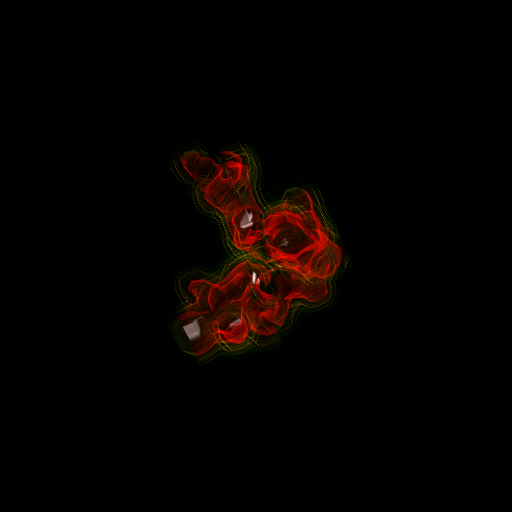

yt : [INFO     ] 2025-02-11 18:30:37,590 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:37,590 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:37,591 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:37,591 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:37,591 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:37,633 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:37,640 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:37,641 Creating volume
yt : [INFO     ] 2025-02-11 18:30:37,657 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:37,657 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


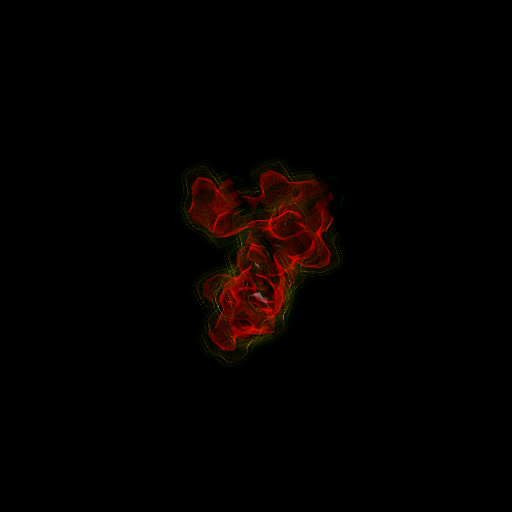

yt : [INFO     ] 2025-02-11 18:30:37,788 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:37,788 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:37,788 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:37,788 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:37,788 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:37,831 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:37,837 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:37,838 Creating volume
yt : [INFO     ] 2025-02-11 18:30:37,853 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:37,853 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


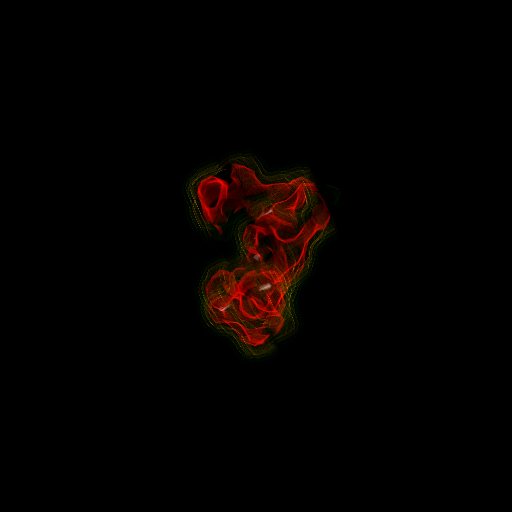

yt : [INFO     ] 2025-02-11 18:30:38,019 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:38,019 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:38,019 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:38,020 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:38,020 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:38,061 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:38,067 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:38,068 Creating volume
yt : [INFO     ] 2025-02-11 18:30:38,084 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:38,084 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


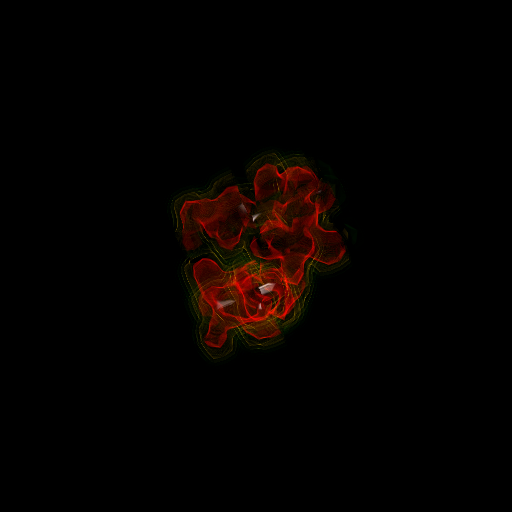

yt : [INFO     ] 2025-02-11 18:30:38,219 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:38,219 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:38,219 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:38,219 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:38,219 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:38,316 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:38,322 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:38,323 Creating volume
yt : [INFO     ] 2025-02-11 18:30:38,338 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:38,338 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


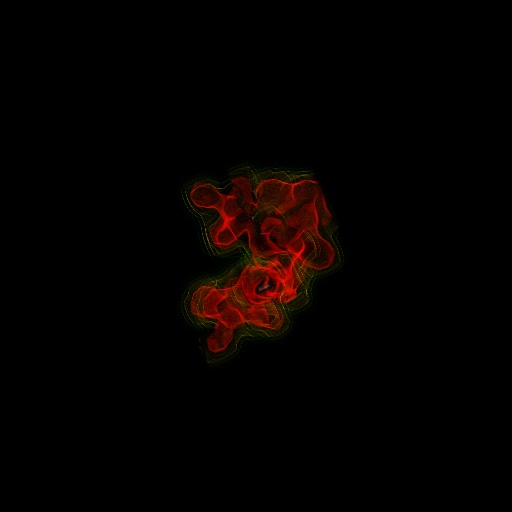

yt : [INFO     ] 2025-02-11 18:30:38,471 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:38,471 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:38,471 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:38,471 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:38,472 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:38,512 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:38,519 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:38,520 Creating volume
yt : [INFO     ] 2025-02-11 18:30:38,535 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:38,535 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


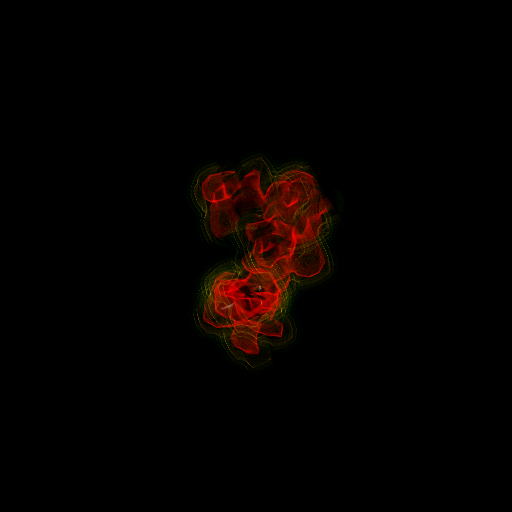

yt : [INFO     ] 2025-02-11 18:30:38,667 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:38,667 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:38,667 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:38,668 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:38,668 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:38,709 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:38,716 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:38,716 Creating volume
yt : [INFO     ] 2025-02-11 18:30:38,732 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:38,733 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


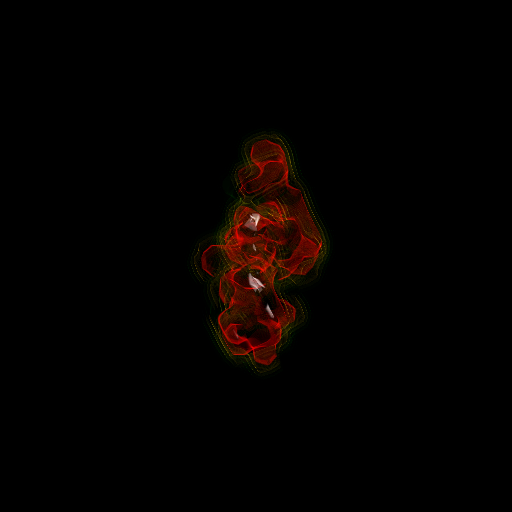

yt : [INFO     ] 2025-02-11 18:30:38,907 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:38,907 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:38,907 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:38,907 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:38,908 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:38,950 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:38,956 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:38,957 Creating volume
yt : [INFO     ] 2025-02-11 18:30:38,973 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:38,973 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


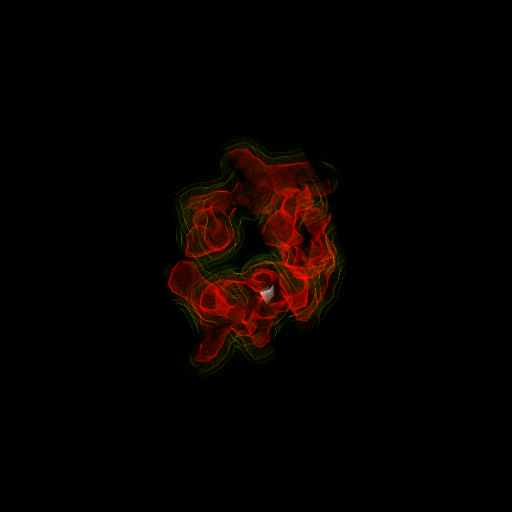

yt : [INFO     ] 2025-02-11 18:30:39,136 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:39,136 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:39,136 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:39,137 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:39,137 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:39,178 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:39,185 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:39,185 Creating volume
yt : [INFO     ] 2025-02-11 18:30:39,201 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:39,201 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


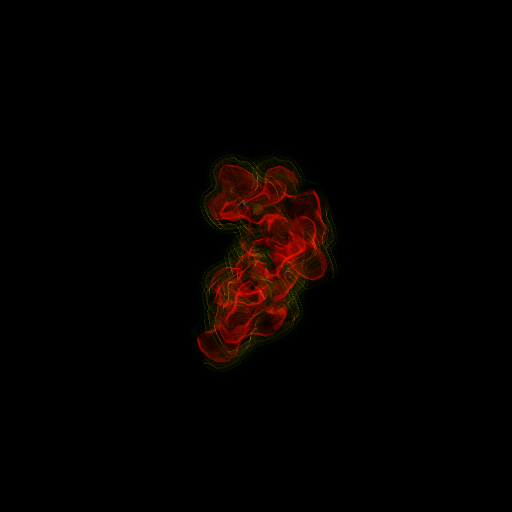

yt : [INFO     ] 2025-02-11 18:30:39,342 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:39,342 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:39,342 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:39,343 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:39,343 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:39,386 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:39,392 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:39,393 Creating volume
yt : [INFO     ] 2025-02-11 18:30:39,409 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:39,409 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


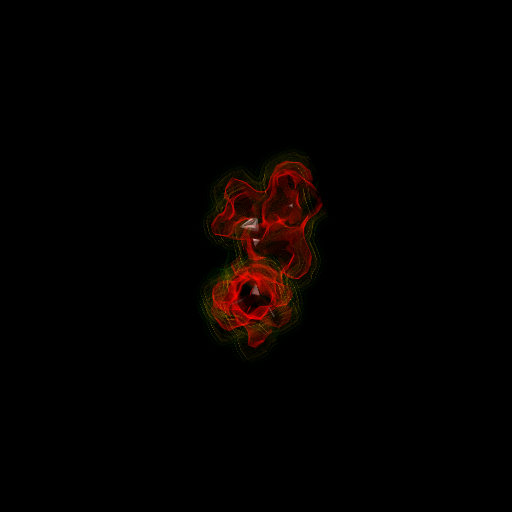

yt : [INFO     ] 2025-02-11 18:30:39,540 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:39,541 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:39,541 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:39,541 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:39,541 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:39,585 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:39,591 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:39,592 Creating volume
yt : [INFO     ] 2025-02-11 18:30:39,608 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:39,608 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


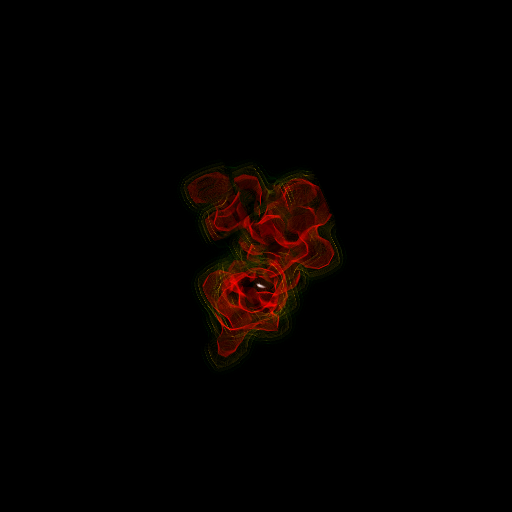

yt : [INFO     ] 2025-02-11 18:30:39,779 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:39,779 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:39,780 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:39,780 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:39,780 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:39,822 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:39,828 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:39,829 Creating volume
yt : [INFO     ] 2025-02-11 18:30:39,844 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:39,844 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


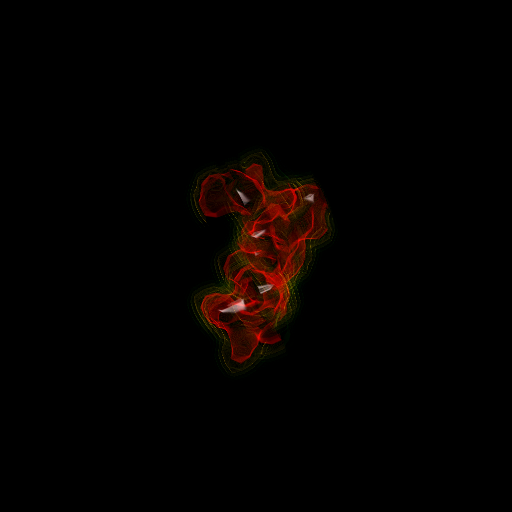

yt : [INFO     ] 2025-02-11 18:30:39,991 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:39,991 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:39,991 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:39,991 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:39,991 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:40,034 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:40,041 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:40,042 Creating volume
yt : [INFO     ] 2025-02-11 18:30:40,063 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:40,064 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


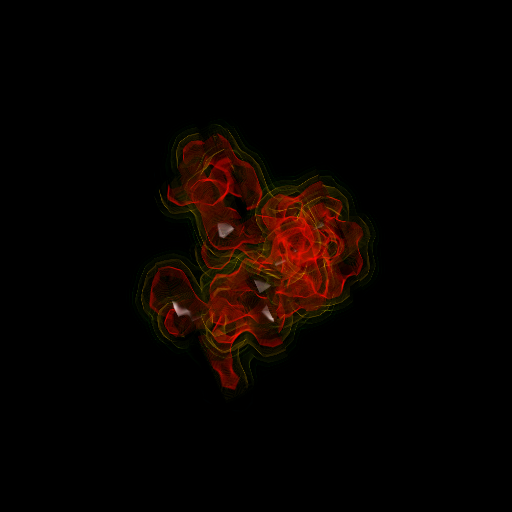

yt : [INFO     ] 2025-02-11 18:30:40,215 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:40,215 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:40,215 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:40,215 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:40,216 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:40,258 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:40,265 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:40,266 Creating volume
yt : [INFO     ] 2025-02-11 18:30:40,282 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:40,282 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


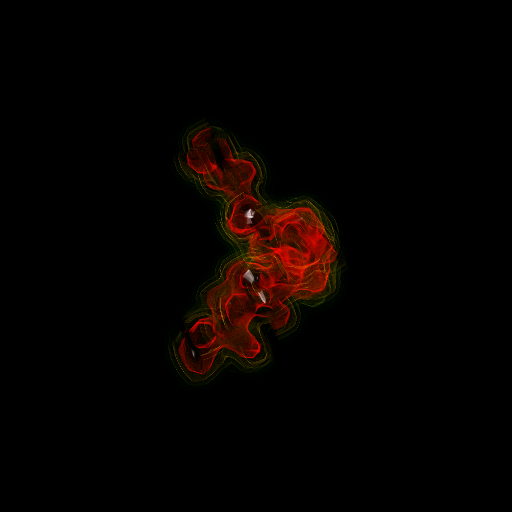

yt : [INFO     ] 2025-02-11 18:30:40,417 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:40,417 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:40,418 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:40,418 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:40,418 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:40,463 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:40,470 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:40,471 Creating volume
yt : [INFO     ] 2025-02-11 18:30:40,487 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:40,487 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


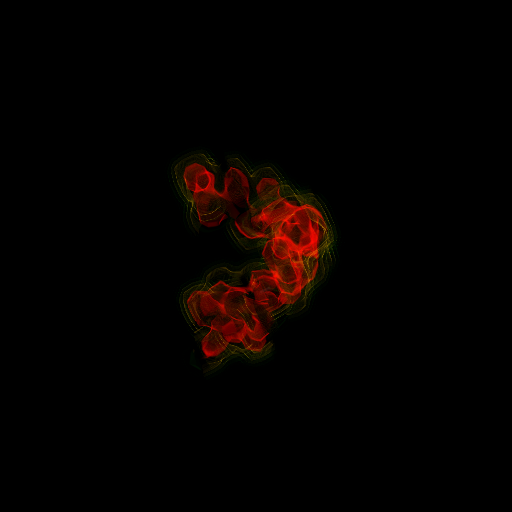

yt : [INFO     ] 2025-02-11 18:30:40,660 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:40,660 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:40,660 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:40,660 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:40,661 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:40,702 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:40,709 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:40,709 Creating volume
yt : [INFO     ] 2025-02-11 18:30:40,725 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:40,725 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


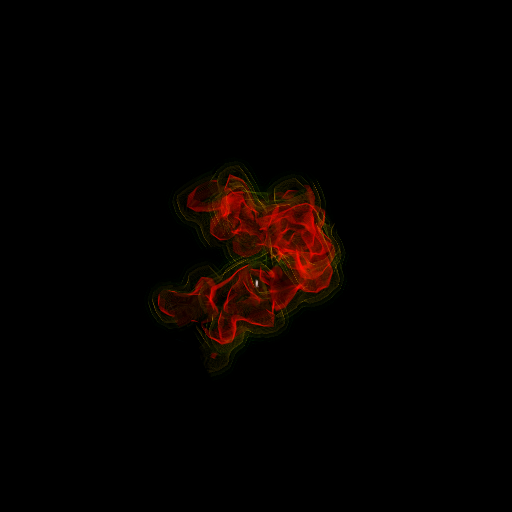

yt : [INFO     ] 2025-02-11 18:30:40,864 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:40,864 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:40,864 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:40,864 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:40,865 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:40,908 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:40,915 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:40,916 Creating volume
yt : [INFO     ] 2025-02-11 18:30:40,936 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:40,937 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


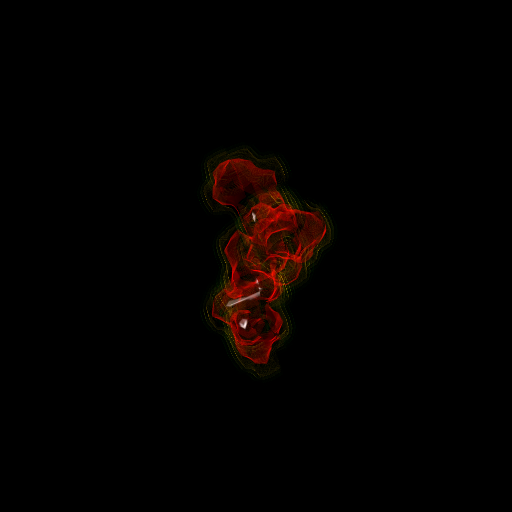

yt : [INFO     ] 2025-02-11 18:30:41,078 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:41,079 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:41,079 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:41,079 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:41,079 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:41,189 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:41,195 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:41,196 Creating volume
yt : [INFO     ] 2025-02-11 18:30:41,211 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:41,211 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


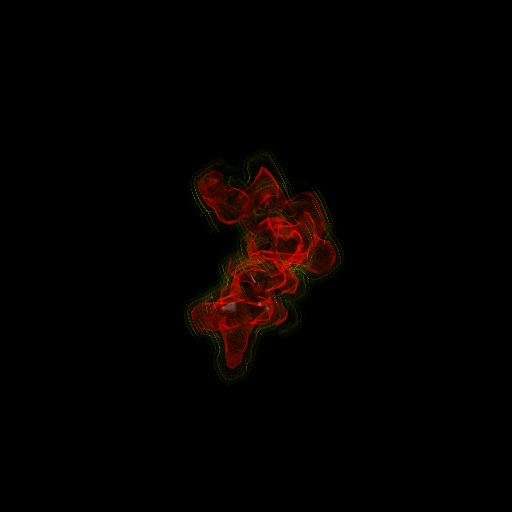

yt : [INFO     ] 2025-02-11 18:30:41,357 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:30:41,357 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:30:41,357 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:30:41,357 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:30:41,357 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:30:41,398 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:30:41,405 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:30:41,405 Creating volume
yt : [INFO     ] 2025-02-11 18:30:41,423 Creating transfer function
yt : [INFO     ] 2025-02-11 18:30:41,423 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


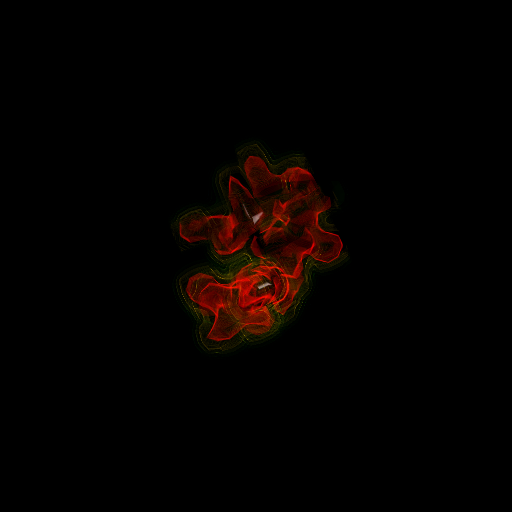

In [4]:
for batch in dl_test:
    for field in batch:
        plot_field(field[:, :, :, 0], cam_rotate=rotation).show()

In [5]:
net = SirenNet(
    dim_in=4,
    dim_hidden=256,
    dim_out=1,
    num_layers=8,
    w0 = 1.0,
    w0_initial = 30.0,
    use_bias = True,
    final_activation = None
)

autoencoder = Autoencoder(
    net,
    in_channels=1,
    output_shape=[resolution, resolution, resolution, 1, 1],
    latent_dim=256,
)

autoencoder.cuda()

optim = torch.optim.Adam(lr=1e-4, params=autoencoder.parameters())

/home/daenu/micromamba/envs/minf/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [8]:
for epoch in (pbar := tqdm(range(10000))):
    total_loss = 0
    for batch in dl:
        loss, out, latent = autoencoder(batch.cuda())
        optim.zero_grad()
        loss.backward()
        optim.step()

        total_loss += loss.item()
    torch.save(autoencoder.state_dict(), "model.pt")
    pbar.set_description(f"Epoch {epoch} (loss: {(total_loss / len(fd)):2f})")

Epoch 23 (loss: 0.001665):   0%|▏                                                                       | 24/10000 [00:11<1:17:17,  2.15it/s]


KeyboardInterrupt: 

yt : [INFO     ] 2025-02-11 18:36:08,260 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:08,260 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:08,260 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:08,260 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:08,260 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:08,302 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:08,309 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:08,309 Creating volume
yt : [INFO     ] 2025-02-11 18:36:08,326 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:08,326 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


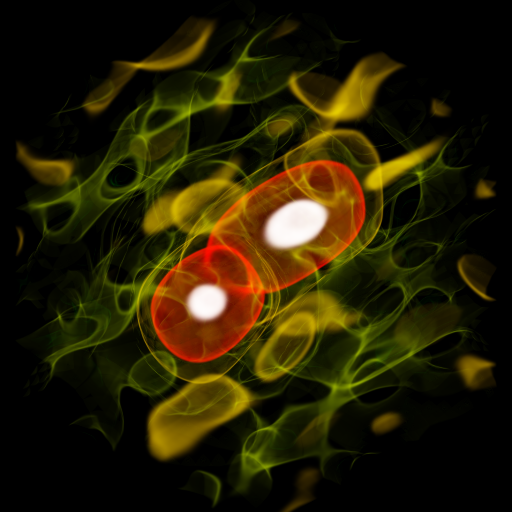

yt : [INFO     ] 2025-02-11 18:36:08,617 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:08,617 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:08,617 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:08,618 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:08,618 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:08,658 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:08,665 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:08,667 Creating volume
yt : [INFO     ] 2025-02-11 18:36:08,682 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:08,683 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


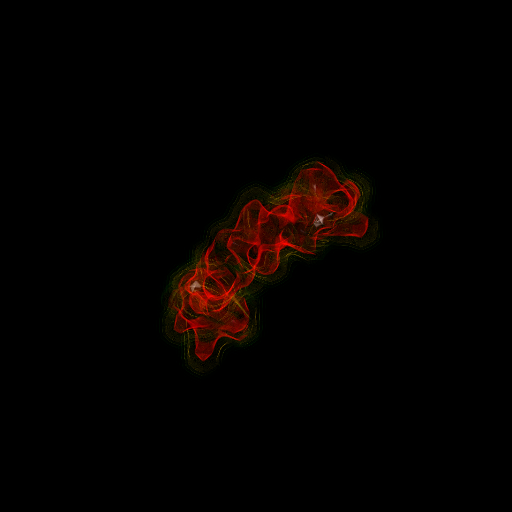

yt : [INFO     ] 2025-02-11 18:36:08,828 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:08,829 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:08,829 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:08,829 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:08,829 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:08,948 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:08,955 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:08,956 Creating volume
yt : [INFO     ] 2025-02-11 18:36:08,972 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:08,972 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


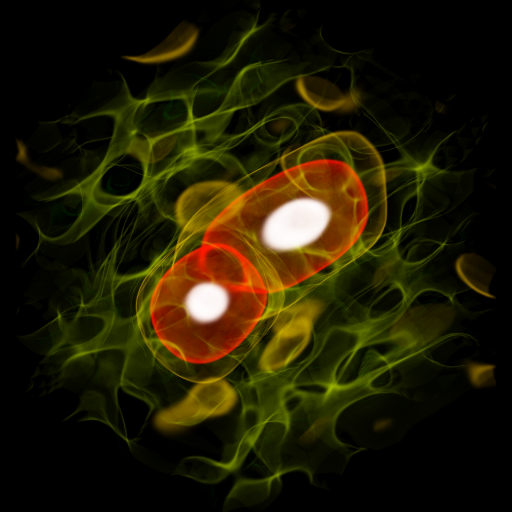

yt : [INFO     ] 2025-02-11 18:36:09,253 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:09,254 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:09,254 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:09,254 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:09,254 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:09,295 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:09,302 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:09,302 Creating volume
yt : [INFO     ] 2025-02-11 18:36:09,318 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:09,318 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


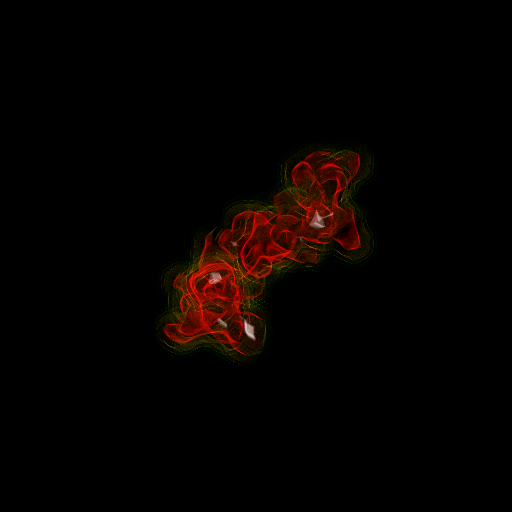

yt : [INFO     ] 2025-02-11 18:36:09,484 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:09,484 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:09,485 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:09,485 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:09,485 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:09,525 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:09,532 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:09,533 Creating volume
yt : [INFO     ] 2025-02-11 18:36:09,549 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:09,549 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


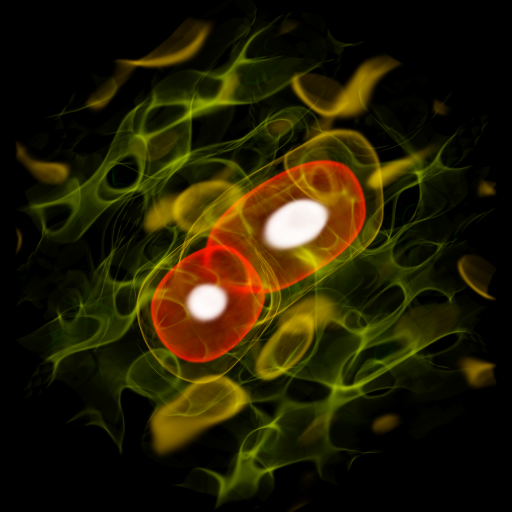

yt : [INFO     ] 2025-02-11 18:36:09,841 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:09,841 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:09,842 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:09,842 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:09,842 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:09,884 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:09,891 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:09,891 Creating volume
yt : [INFO     ] 2025-02-11 18:36:09,907 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:09,908 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


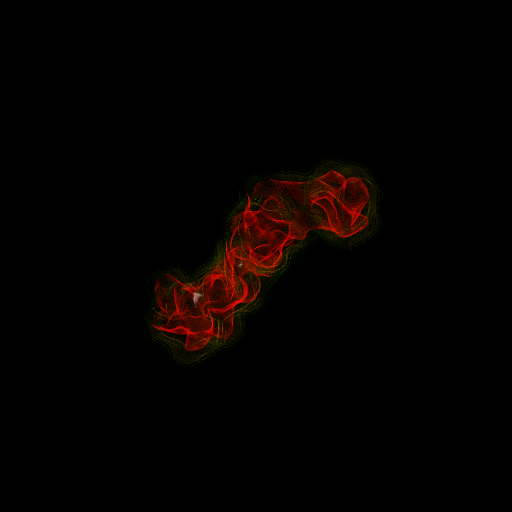

yt : [INFO     ] 2025-02-11 18:36:10,054 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:10,054 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:10,055 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:10,055 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:10,055 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:10,099 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:10,105 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:10,106 Creating volume
yt : [INFO     ] 2025-02-11 18:36:10,122 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:10,122 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


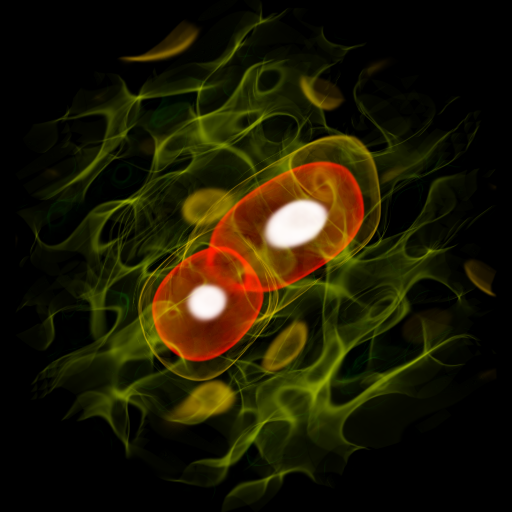

yt : [INFO     ] 2025-02-11 18:36:10,397 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:10,397 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:10,398 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:10,398 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:10,398 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:10,441 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:10,448 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:10,449 Creating volume
yt : [INFO     ] 2025-02-11 18:36:10,464 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:10,464 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


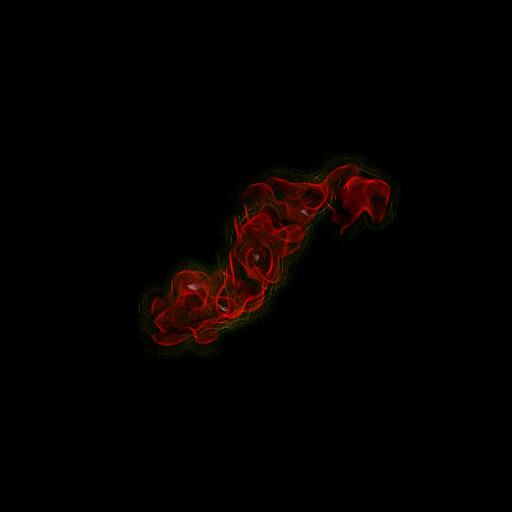

yt : [INFO     ] 2025-02-11 18:36:10,643 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:10,643 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:10,643 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:10,643 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:10,644 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:10,687 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:10,694 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:10,695 Creating volume
yt : [INFO     ] 2025-02-11 18:36:10,711 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:10,711 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


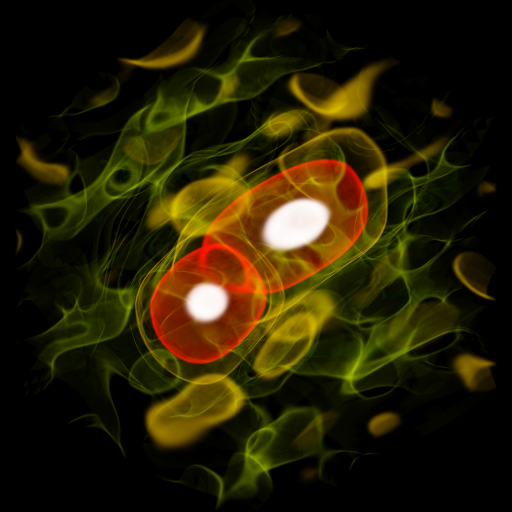

yt : [INFO     ] 2025-02-11 18:36:11,013 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:11,014 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:11,014 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:11,014 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:11,014 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:11,056 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:11,063 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:11,063 Creating volume
yt : [INFO     ] 2025-02-11 18:36:11,079 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:11,080 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


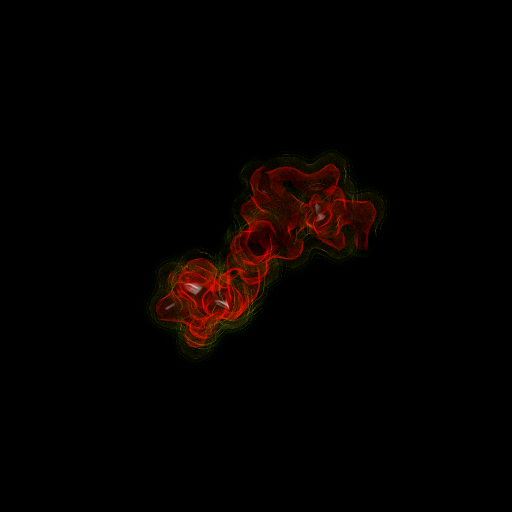

yt : [INFO     ] 2025-02-11 18:36:11,239 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:11,240 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:11,240 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:11,240 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:11,240 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:11,282 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:11,289 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:11,289 Creating volume
yt : [INFO     ] 2025-02-11 18:36:11,305 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:11,305 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


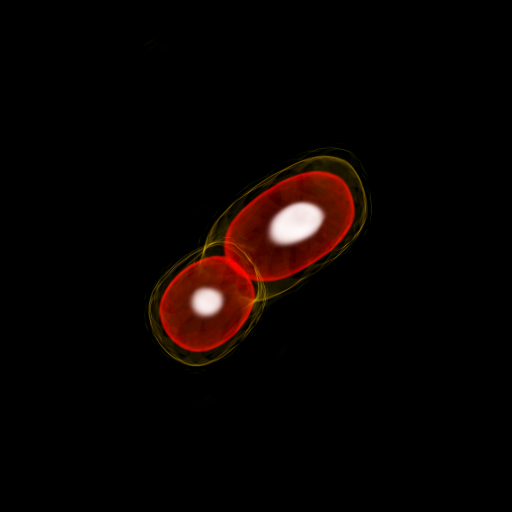

yt : [INFO     ] 2025-02-11 18:36:11,464 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:11,465 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:11,465 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:11,465 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:11,465 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:11,508 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:11,515 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:11,515 Creating volume
yt : [INFO     ] 2025-02-11 18:36:11,531 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:11,531 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


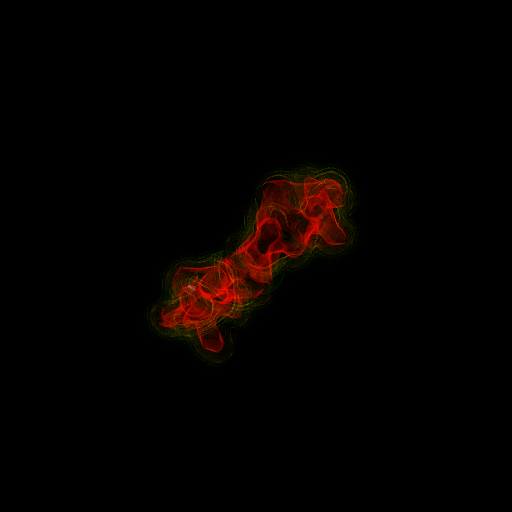

yt : [INFO     ] 2025-02-11 18:36:11,691 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:11,692 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:11,692 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:11,692 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:11,692 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:11,735 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:11,742 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:11,743 Creating volume
yt : [INFO     ] 2025-02-11 18:36:11,758 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:11,759 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


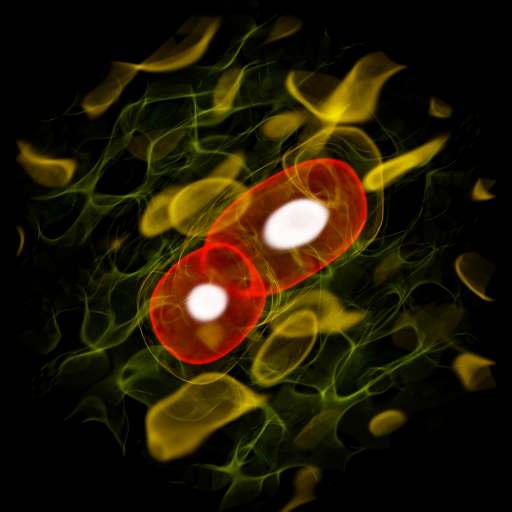

yt : [INFO     ] 2025-02-11 18:36:12,017 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:12,017 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:12,018 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:12,018 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:12,018 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:12,060 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:12,066 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:12,067 Creating volume
yt : [INFO     ] 2025-02-11 18:36:12,083 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:12,083 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


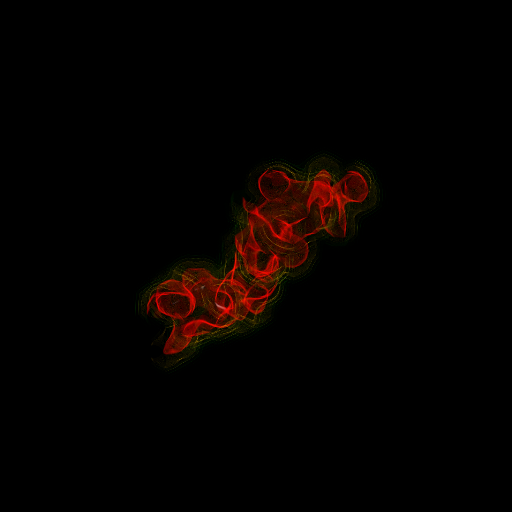

yt : [INFO     ] 2025-02-11 18:36:12,234 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:12,234 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:12,234 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:12,234 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:12,234 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:12,276 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:12,283 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:12,283 Creating volume
yt : [INFO     ] 2025-02-11 18:36:12,299 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:12,299 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


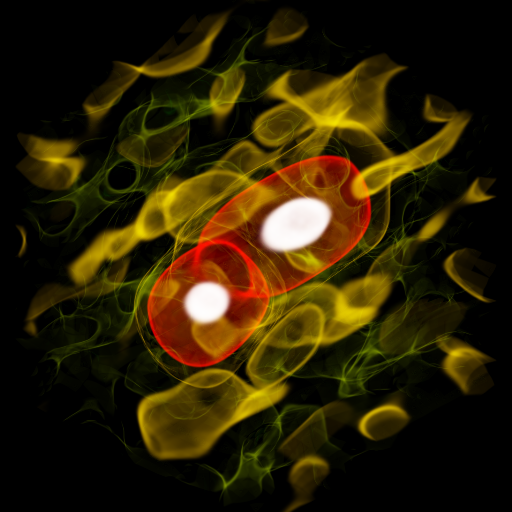

yt : [INFO     ] 2025-02-11 18:36:12,558 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:12,558 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:12,558 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:12,559 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:12,559 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:12,601 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:12,607 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:12,608 Creating volume
yt : [INFO     ] 2025-02-11 18:36:12,624 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:12,624 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


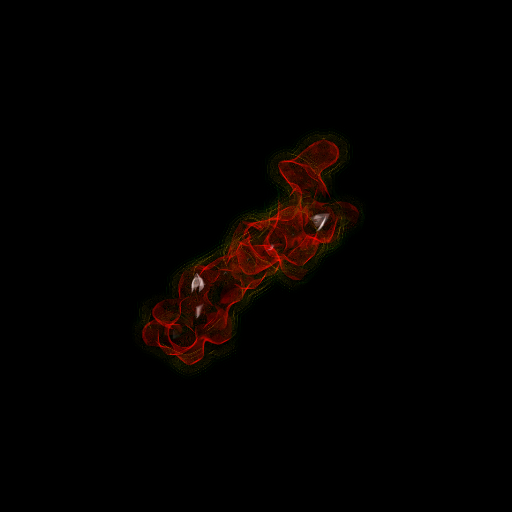

yt : [INFO     ] 2025-02-11 18:36:12,816 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:12,817 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:12,817 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:12,817 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:12,817 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:12,860 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:12,866 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:12,867 Creating volume
yt : [INFO     ] 2025-02-11 18:36:12,883 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:12,883 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


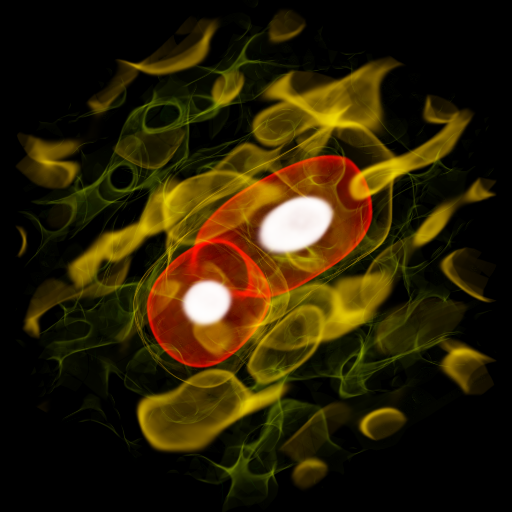

yt : [INFO     ] 2025-02-11 18:36:13,148 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:13,148 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:13,148 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:13,149 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:13,149 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:13,192 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:13,199 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:13,200 Creating volume
yt : [INFO     ] 2025-02-11 18:36:13,215 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:13,215 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


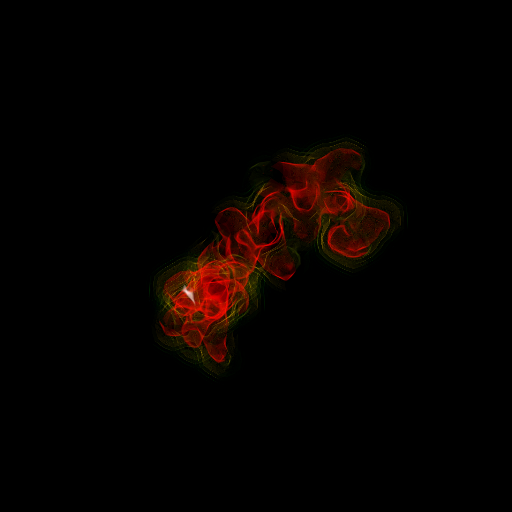

yt : [INFO     ] 2025-02-11 18:36:13,365 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:13,365 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:13,365 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:13,365 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:13,366 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:13,493 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:13,499 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:13,500 Creating volume
yt : [INFO     ] 2025-02-11 18:36:13,515 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:13,515 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


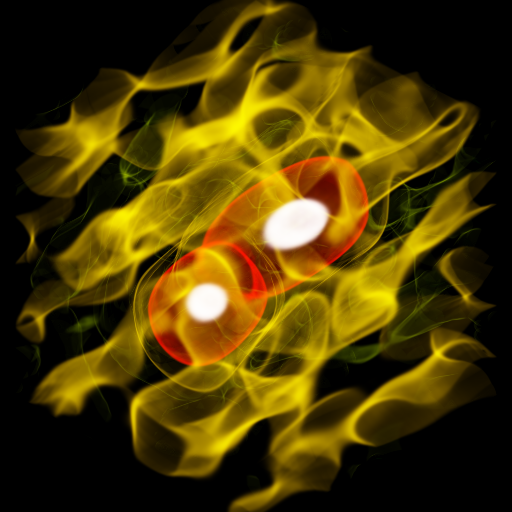

yt : [INFO     ] 2025-02-11 18:36:13,833 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:13,834 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:13,834 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:13,834 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:13,834 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:13,875 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:13,881 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:13,882 Creating volume
yt : [INFO     ] 2025-02-11 18:36:13,897 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:13,897 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


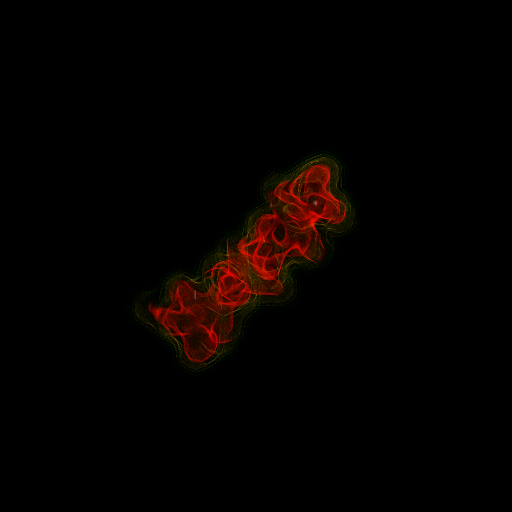

yt : [INFO     ] 2025-02-11 18:36:14,046 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:14,046 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:14,046 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:14,046 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:14,046 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:14,088 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:14,094 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:14,095 Creating volume
yt : [INFO     ] 2025-02-11 18:36:14,111 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:14,111 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


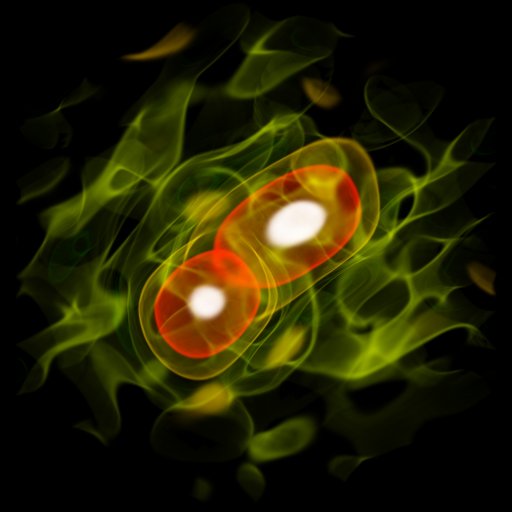

yt : [INFO     ] 2025-02-11 18:36:14,538 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:14,538 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:14,538 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:14,539 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:14,539 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:14,579 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:14,586 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:14,586 Creating volume
yt : [INFO     ] 2025-02-11 18:36:14,602 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:14,602 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


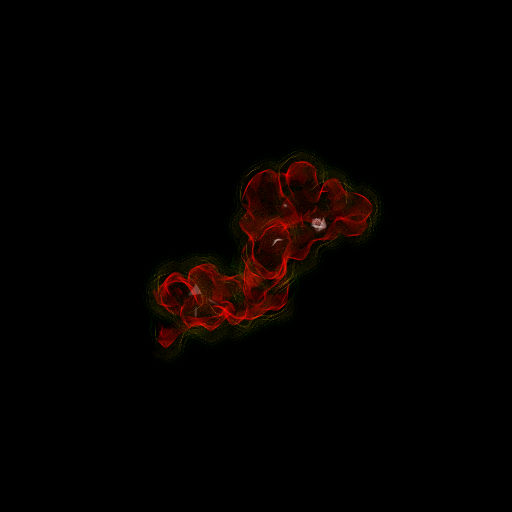

yt : [INFO     ] 2025-02-11 18:36:14,747 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:14,747 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:14,747 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:14,747 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:14,747 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:14,789 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:14,796 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:14,796 Creating volume
yt : [INFO     ] 2025-02-11 18:36:14,813 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:14,813 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


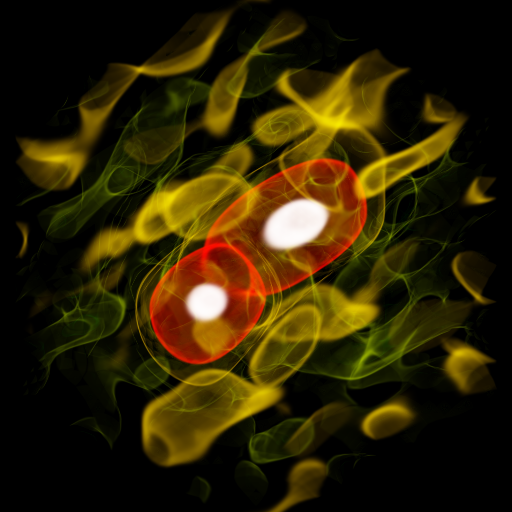

yt : [INFO     ] 2025-02-11 18:36:15,122 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:15,122 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:15,123 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:15,123 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:15,123 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:15,163 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:15,170 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:15,170 Creating volume
yt : [INFO     ] 2025-02-11 18:36:15,186 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:15,186 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


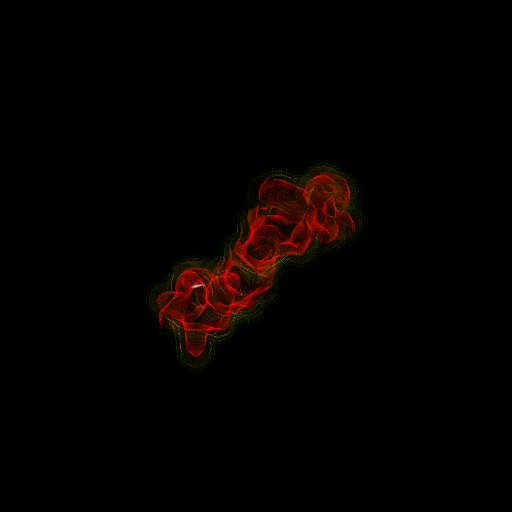

yt : [INFO     ] 2025-02-11 18:36:15,376 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:15,376 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:15,376 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:15,376 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:15,376 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:15,416 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:15,422 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:15,423 Creating volume
yt : [INFO     ] 2025-02-11 18:36:15,439 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:15,439 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


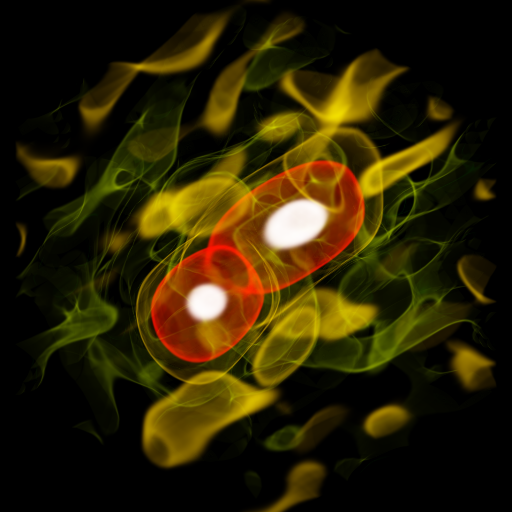

yt : [INFO     ] 2025-02-11 18:36:15,772 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:15,772 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:15,772 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:15,772 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:15,772 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:15,813 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:15,820 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:15,820 Creating volume
yt : [INFO     ] 2025-02-11 18:36:15,836 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:15,836 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


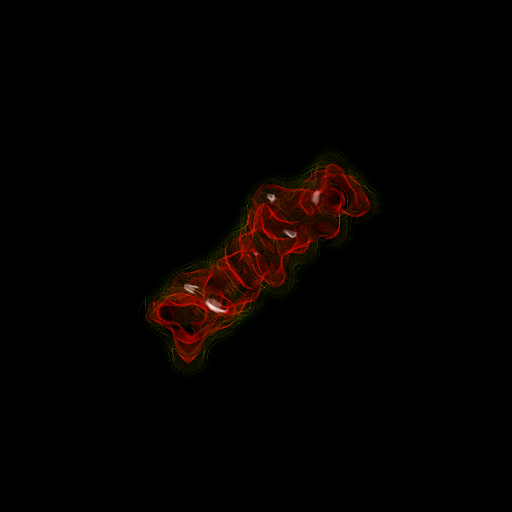

yt : [INFO     ] 2025-02-11 18:36:15,990 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:15,990 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:15,990 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:15,991 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:15,991 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:16,031 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:16,038 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:16,038 Creating volume
yt : [INFO     ] 2025-02-11 18:36:16,054 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:16,054 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


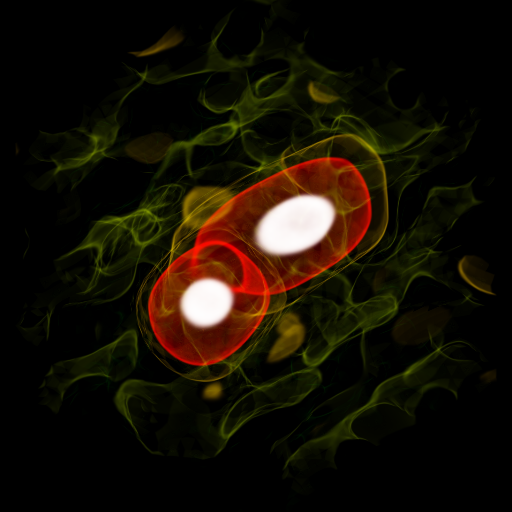

yt : [INFO     ] 2025-02-11 18:36:16,280 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:16,280 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:16,280 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:16,280 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:16,280 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:16,321 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:16,327 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:16,328 Creating volume
yt : [INFO     ] 2025-02-11 18:36:16,344 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:16,344 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


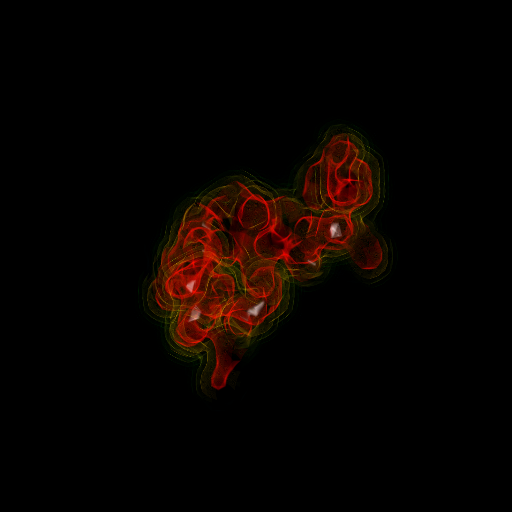

yt : [INFO     ] 2025-02-11 18:36:16,504 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:16,504 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:16,505 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:16,505 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:16,505 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:16,546 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:16,552 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:16,553 Creating volume
yt : [INFO     ] 2025-02-11 18:36:16,568 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:16,568 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


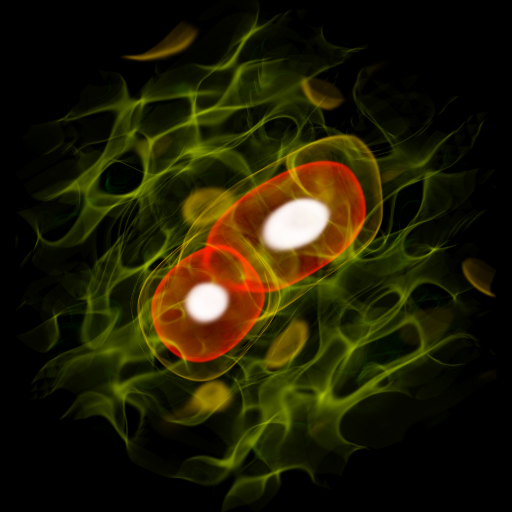

yt : [INFO     ] 2025-02-11 18:36:16,855 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:16,855 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:16,855 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:16,856 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:16,856 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:16,897 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:16,903 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:16,904 Creating volume
yt : [INFO     ] 2025-02-11 18:36:16,920 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:16,920 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


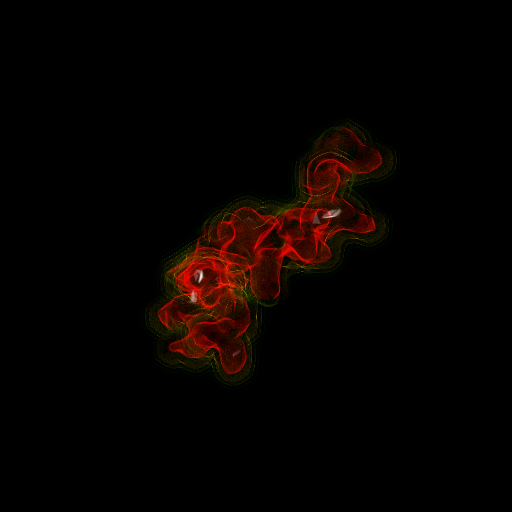

yt : [INFO     ] 2025-02-11 18:36:17,083 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:17,084 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:17,084 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:17,084 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:17,084 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:17,125 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:17,131 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:17,132 Creating volume
yt : [INFO     ] 2025-02-11 18:36:17,148 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:17,148 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


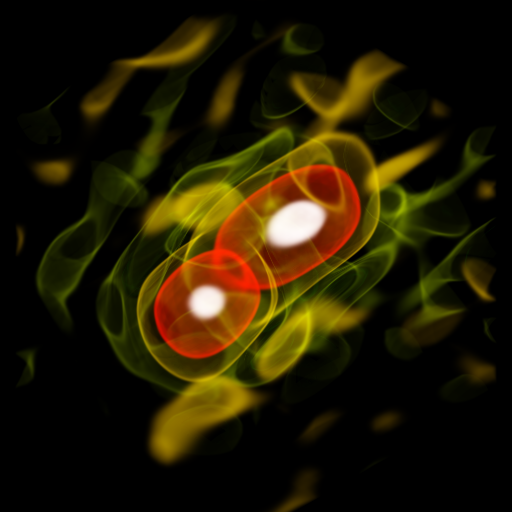

yt : [INFO     ] 2025-02-11 18:36:17,466 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:17,467 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:17,467 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:17,467 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:17,467 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:17,507 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:17,514 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:17,515 Creating volume
yt : [INFO     ] 2025-02-11 18:36:17,530 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:17,530 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


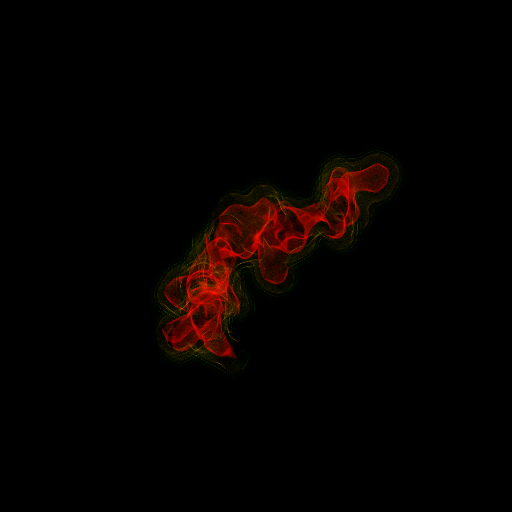

yt : [INFO     ] 2025-02-11 18:36:17,716 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:17,717 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:17,717 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:17,717 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:17,717 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:17,758 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:17,764 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:17,765 Creating volume
yt : [INFO     ] 2025-02-11 18:36:17,781 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:17,781 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


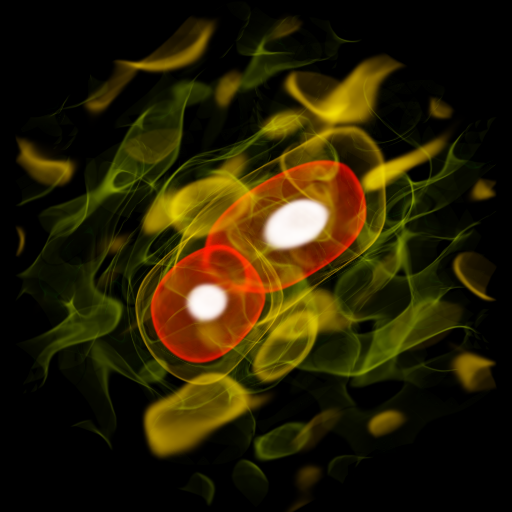

yt : [INFO     ] 2025-02-11 18:36:18,110 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:18,110 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:18,110 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:18,110 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:18,110 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:18,152 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:18,158 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:18,159 Creating volume
yt : [INFO     ] 2025-02-11 18:36:18,174 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:18,175 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


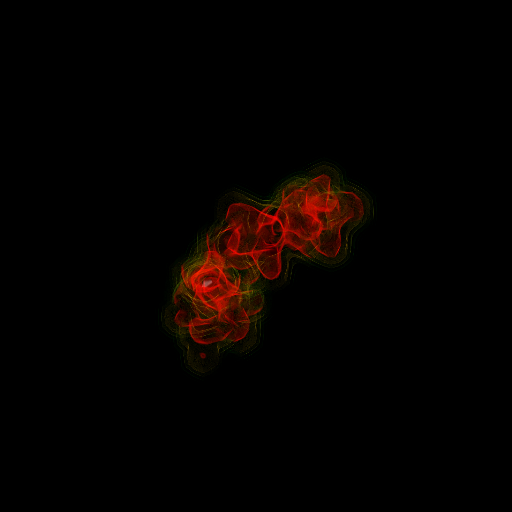

yt : [INFO     ] 2025-02-11 18:36:18,333 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:18,333 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:18,333 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:18,334 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:18,334 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:18,376 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:18,382 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:18,383 Creating volume
yt : [INFO     ] 2025-02-11 18:36:18,399 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:18,399 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


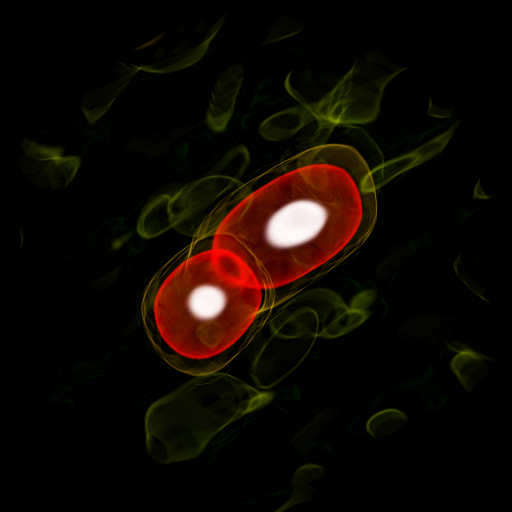

yt : [INFO     ] 2025-02-11 18:36:18,589 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:18,589 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:18,589 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:18,590 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:18,590 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:18,739 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:18,745 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:18,746 Creating volume
yt : [INFO     ] 2025-02-11 18:36:18,762 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:18,762 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


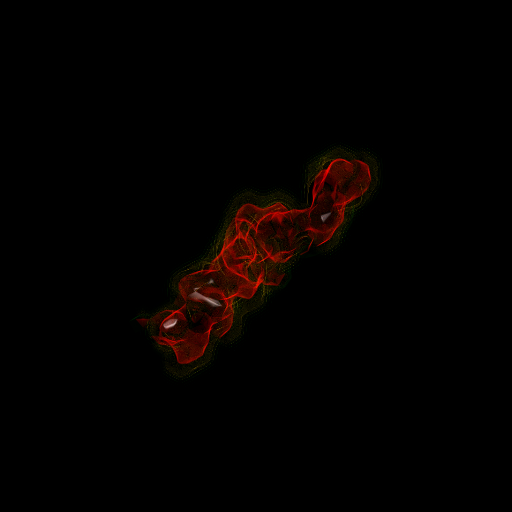

yt : [INFO     ] 2025-02-11 18:36:18,910 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:18,910 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:18,910 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:18,911 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:18,911 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:18,951 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:18,958 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:18,959 Creating volume
yt : [INFO     ] 2025-02-11 18:36:18,975 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:18,975 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


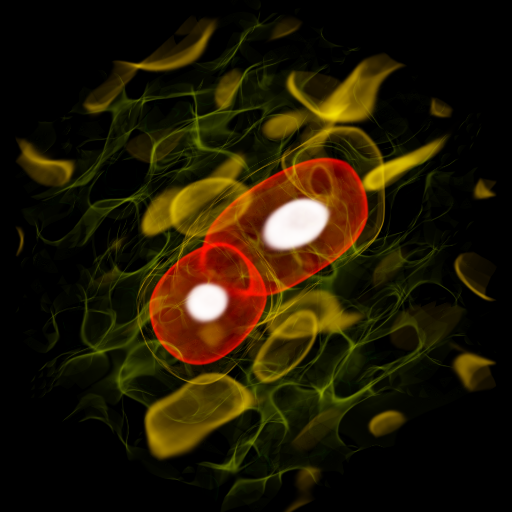

yt : [INFO     ] 2025-02-11 18:36:19,239 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:19,239 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:19,239 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:19,239 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:19,239 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:19,280 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:19,286 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:19,287 Creating volume
yt : [INFO     ] 2025-02-11 18:36:19,303 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:19,303 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


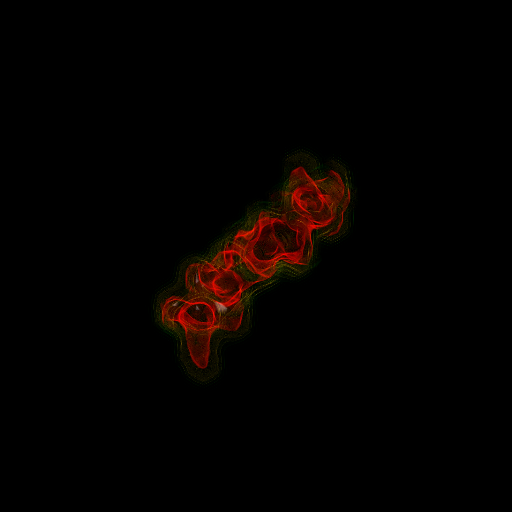

yt : [INFO     ] 2025-02-11 18:36:19,448 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:19,448 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:19,448 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:19,448 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:19,449 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:19,489 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:19,495 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:19,496 Creating volume
yt : [INFO     ] 2025-02-11 18:36:19,512 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:19,512 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


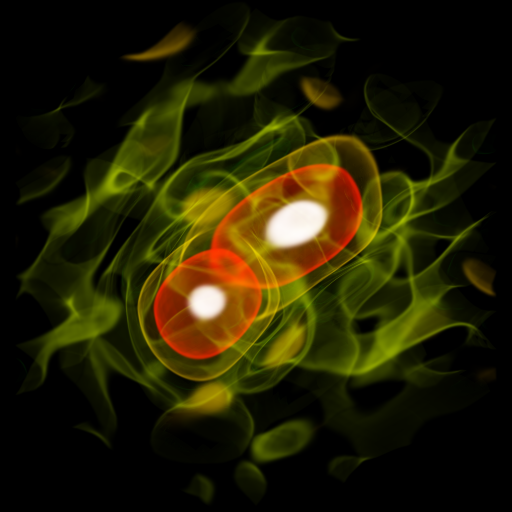

yt : [INFO     ] 2025-02-11 18:36:19,976 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:36:19,976 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 18:36:19,977 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:36:19,977 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:36:19,977 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:36:20,018 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:36:20,025 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:36:20,026 Creating volume
yt : [INFO     ] 2025-02-11 18:36:20,043 Creating transfer function
yt : [INFO     ] 2025-02-11 18:36:20,043 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


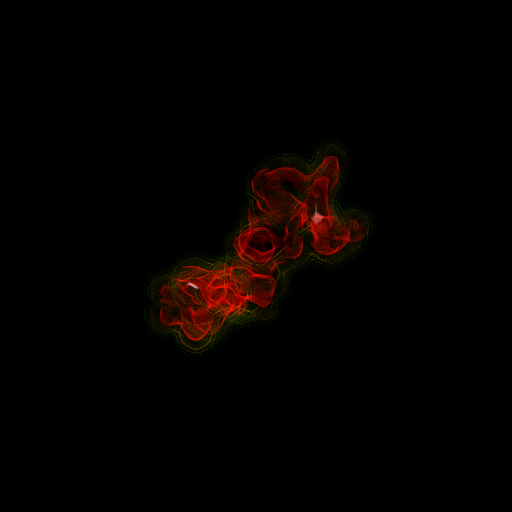

In [7]:
i = 0
for batch in dl_test:
    latent = autoencoder.encode(batch.cuda())
    reconstructed = autoencoder.predict(latent).cpu().detach()
    
    for r in reconstructed:
        plot_field(r.flatten(3)[:, :, :, 0]).show()
        print("gt")
        plot_field(fd[i][:, :, :, 0]).show()
        i += 1

In [ ]:
def interp(arr1, arr2, num_points):
    fractions = np.linspace(0, 1, num_points)
    return np.array([arr1 + (arr2 - arr1) * f for f in fractions])

In [ ]:
latents = []

for batch in dl_test:
    lats = autoencoder.encode(batch.cuda())
    for lat in lats:
        latents.append(lat.cpu().detach())

latents_intrp = interp(latents[0], latents[5], 10)
reconstructed = autoencoder.predict(torch.FloatTensor(latents_intrp).cuda()).cpu().detach()

for r in reconstructed:
    reconstructed = reconstructed.cpu().detach().squeeze(-1)
    plot_field(r.flatten(3)[:, :, :, 0]).show()